# THESIS-GRADE: AI-Gated Portfolio with Graph-Based Selection

## Research Questions
**RQ1:** AI-gated vs Static? (H1: AI > Static, α=0.05)
**RQ2:** Diversify vs Cluster? (H1: Diversify ≠ Cluster, α=0.05)
**RQ3:** Component contribution? (Ablation study)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
from scipy import stats
import networkx as nx
from sklearn.metrics import fbeta_score, classification_report
import warnings
warnings.filterwarnings('ignore')

SEED = 42
ALPHA = 0.05
np.random.seed(SEED)
print("✓ Loaded")

✓ Loaded


In [2]:
# Load data
data = pd.read_excel('../experiment_nextLevel2/dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

# Features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(20).std()
features['Mom_20'] = market_return.rolling(20).mean()
features['Mom_50'] = market_return.rolling(50).mean()

sma5 = market_return.rolling(5).mean()
sma20 = market_return.rolling(20).mean()
target = (sma5 > sma20).astype(int).shift(-5).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]

print(f"Train: {len(X_train)}, Test: {len(returns[returns.index.year==2025])}")

Train: 562, Test: 365


In [3]:
# Train model with optimized threshold
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=SEED)
model.fit(X_train, y_train)

train_probs = model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.3, 0.7, 41)
f_scores = [fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in thresholds]
opt_t = thresholds[np.argmax(f_scores)]

X_all = features.dropna()
all_probs = pd.Series(model.predict_proba(X_all)[:, 1], index=X_all.index).reindex(returns.index, method='ffill')

print(f"Threshold: {opt_t:.2f}, F-beta: {max(f_scores):.3f}")

Threshold: 0.54, F-beta: 0.895


In [4]:
# Helper functions
def optimize_markowitz(rets):
    if len(rets.columns) == 0: return {}
    if len(rets.columns) == 1: return {rets.columns[0]: 1.0}
    mu, sigma = rets.mean() * 252, rets.cov() * 252
    n = len(mu)
    obj = lambda w: -(np.sum(w*mu) / np.sqrt(np.dot(w.T, np.dot(sigma, w))))
    res = minimize(obj, [1./n]*n, method='SLSQP', bounds=[(0,1)]*n, constraints={'type':'eq','fun':lambda x:np.sum(x)-1})
    return dict(zip(rets.columns, res.x)) if res.success else {}

def graph_diversify(rets, th=0.4):
    corr = rets.corr()
    assets = list(rets.mean().sort_values(ascending=False).index)
    G = nx.Graph()
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr.loc[assets[i], assets[j]]) > th:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def graph_cluster(rets, th=0.4):
    corr = rets.corr()
    assets = list(rets.mean().sort_values(ascending=False).index)
    G = nx.Graph()
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr.loc[assets[i], assets[j]]) < th:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

print("✓ Functions ready")

✓ Functions ready


In [5]:
# Simulation function
def simulate(dates, rets, prob_series, threshold, market_idx, selector, use_ai=True, override_ma=200):
    val, hist, ds = 100.0, [100.0], [dates[0]]
    weights, risk_on, days = {}, False, 999
    ma = market_idx.rolling(override_ma).mean() if override_ma else None
    
    for i, d in enumerate(dates[:-1]):
        prob = prob_series.loc[d] if use_ai else 1.0
        prev_risk = risk_on
        
        if use_ai:
            if not risk_on and prob > threshold + 0.05: risk_on = True
            elif risk_on and prob < threshold - 0.05: risk_on = False
            if ma is not None and not pd.isna(ma.loc[d]) and not pd.isna(market_idx.loc[d]):
                if not risk_on and market_idx.loc[d] > ma.loc[d]: risk_on = True
        else:
            risk_on = True
        
        target_w = weights.copy()
        if not risk_on:
            target_w = {'CASH': 1.0}
            days = 0
        else:
            if (risk_on != prev_risk) or days >= 20:
                idx = rets.index.get_loc(d)
                window = rets.iloc[max(0, idx-60):idx]
                if len(window) > 0:
                    sel = selector(window) if selector else list(window.columns)
                    opt_w = optimize_markowitz(window[sel]) if len(sel) > 0 else {}
                    if opt_w:
                        turn = sum(abs(opt_w.get(k,0) - weights.get(k,0)) for k in set(list(opt_w.keys())+list(weights.keys())))
                        if (risk_on != prev_risk) or turn > 0.05:
                            target_w, days = opt_w, 0
            days += 1
        
        turn = sum(abs(target_w.get(k,0) - weights.get(k,0)) for k in set(list(target_w.keys())+list(weights.keys())))
        if turn > 0.001: val -= val * turn * 0.0025
        
        nd = dates[i+1]
        if 'CASH' in target_w and target_w['CASH'] > 0.99:
            dr, new_w = 0, {'CASH': 1.0}
        else:
            dr, new_w = 0, {}
            for a, w in target_w.items():
                if a in rets.columns:
                    r = rets.loc[nd, a] if not pd.isna(rets.loc[nd, a]) else 0
                    dr += w * r
                    new_w[a] = w * (1 + r)
            tot = sum(new_w.values())
            new_w = {k: v/tot for k, v in new_w.items()} if tot > 0 else new_w
        
        val *= (1 + dr)
        hist.append(val)
        ds.append(nd)
        weights = new_w
    
    return pd.DataFrame({'value': hist}, index=ds)

print("✓ Simulator ready")

✓ Simulator ready


In [6]:
# Run all strategies for 2025
test_dates = returns[returns.index.year == 2025].index

results_2025 = {
    'AI_Diversify': simulate(test_dates, returns, all_probs, opt_t, market_index, graph_diversify, True, 200),
    'AI_Cluster': simulate(test_dates, returns, all_probs, opt_t, market_index, graph_cluster, True, 200),
    'Static': simulate(test_dates, returns, all_probs, opt_t, market_index, lambda x: list(x.columns), False, None),
    'BuyHold': pd.DataFrame({'value': (1 + market_return.loc[test_dates]).cumprod() * 100}, index=test_dates),
    'EqualWeight': pd.DataFrame({'value': (1 + returns.loc[test_dates].mean(axis=1)).cumprod() * 100}, index=test_dates),
}

# Ablation: AI only, Graph only
results_2025['AI_Only'] = simulate(test_dates, returns, all_probs, opt_t, market_index, lambda x: list(x.columns), True, 200)
results_2025['Graph_Only'] = simulate(test_dates, returns, all_probs, opt_t, market_index, graph_diversify, False, None)

print("✓ Simulations complete")
for k, v in results_2025.items():
    print(f"{k}: {v['value'].iloc[-1]:.2f}")

✓ Simulations complete
AI_Diversify: 101.06
AI_Cluster: 139.59
Static: 105.65
BuyHold: 109.58
EqualWeight: 109.58
AI_Only: 98.49
Graph_Only: 133.40


In [7]:
# Statistical significance testing
def calc_metrics(df):
    v = df['value']
    r = v.pct_change().dropna()
    tr = (v.iloc[-1]/v.iloc[0] - 1) * 100
    vol = r.std() * np.sqrt(252) * 100
    sr = (tr / vol) if vol > 0 else 0
    dd = ((v - v.cummax()) / v.cummax() * 100).min()
    return {'Return%': tr, 'Vol%': vol, 'Sharpe': sr, 'MaxDD%': dd, 'Returns': r}

metrics = {k: calc_metrics(v) for k, v in results_2025.items()}

print("\n=== PERFORMANCE METRICS (2025 Out-of-Sample) ===")
for k, m in metrics.items():
    print(f"{k:15} | Return: {m['Return%']:6.1f}% | Sharpe: {m['Sharpe']:5.2f} | MaxDD: {m['MaxDD%']:6.1f}%")


=== PERFORMANCE METRICS (2025 Out-of-Sample) ===
AI_Diversify    | Return:    1.1% | Sharpe:  0.09 | MaxDD:   -8.9%
AI_Cluster      | Return:   39.6% | Sharpe:  0.76 | MaxDD:  -29.3%
Static          | Return:    5.7% | Sharpe:  0.44 | MaxDD:  -20.3%
BuyHold         | Return:    6.9% | Sharpe:  0.15 | MaxDD:  -38.4%
EqualWeight     | Return:    6.9% | Sharpe:  0.15 | MaxDD:  -38.4%
AI_Only         | Return:   -1.5% | Sharpe: -0.19 | MaxDD:   -7.8%
Graph_Only      | Return:   33.4% | Sharpe:  1.24 | MaxDD:  -16.9%


In [8]:
# Paired t-test: AI_Diversify vs Static
r1 = metrics['AI_Diversify']['Returns']
r2 = metrics['Static']['Returns']
common_idx = r1.index.intersection(r2.index)
t_stat, p_val = stats.ttest_rel(r1.loc[common_idx], r2.loc[common_idx])

print("\n=== RQ1: AI_Diversify vs Static ===")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.4f}")
print(f"Result: {'REJECT H0 (significantly different)' if p_val < ALPHA else 'FAIL TO REJECT H0'}")

# Paired t-test: Diversify vs Cluster
r3 = metrics['AI_Cluster']['Returns']
common_idx2 = r1.index.intersection(r3.index)
t_stat2, p_val2 = stats.ttest_rel(r1.loc[common_idx2], r3.loc[common_idx2])

print("\n=== RQ2: AI_Diversify vs AI_Cluster ===")
print(f"t-statistic: {t_stat2:.3f}")
print(f"p-value: {p_val2:.4f}")
print(f"Result: {'REJECT H0 (significantly different)' if p_val2 < ALPHA else 'FAIL TO REJECT H0'}")


=== RQ1: AI_Diversify vs Static ===
t-statistic: -0.254
p-value: 0.7993
Result: FAIL TO REJECT H0

=== RQ2: AI_Diversify vs AI_Cluster ===
t-statistic: -0.847
p-value: 0.3978
Result: FAIL TO REJECT H0


In [9]:
# Ablation study: Component contribution
print("\n=== RQ3: ABLATION STUDY ===")
print(f"AI Only:        Sharpe = {metrics['AI_Only']['Sharpe']:.2f}")
print(f"Graph Only:     Sharpe = {metrics['Graph_Only']['Sharpe']:.2f}")
print(f"AI + Graph:     Sharpe = {metrics['AI_Diversify']['Sharpe']:.2f}")
print(f"Static:         Sharpe = {metrics['Static']['Sharpe']:.2f}")

improvement_ai = metrics['AI_Diversify']['Sharpe'] - metrics['Graph_Only']['Sharpe']
improvement_graph = metrics['AI_Diversify']['Sharpe'] - metrics['AI_Only']['Sharpe']
print(f"\nMarginal contribution of AI: +{improvement_ai:.2f}")
print(f"Marginal contribution of Graph: +{improvement_graph:.2f}")


=== RQ3: ABLATION STUDY ===
AI Only:        Sharpe = -0.19
Graph Only:     Sharpe = 1.24
AI + Graph:     Sharpe = 0.09
Static:         Sharpe = 0.44

Marginal contribution of AI: +-1.15
Marginal contribution of Graph: +0.27


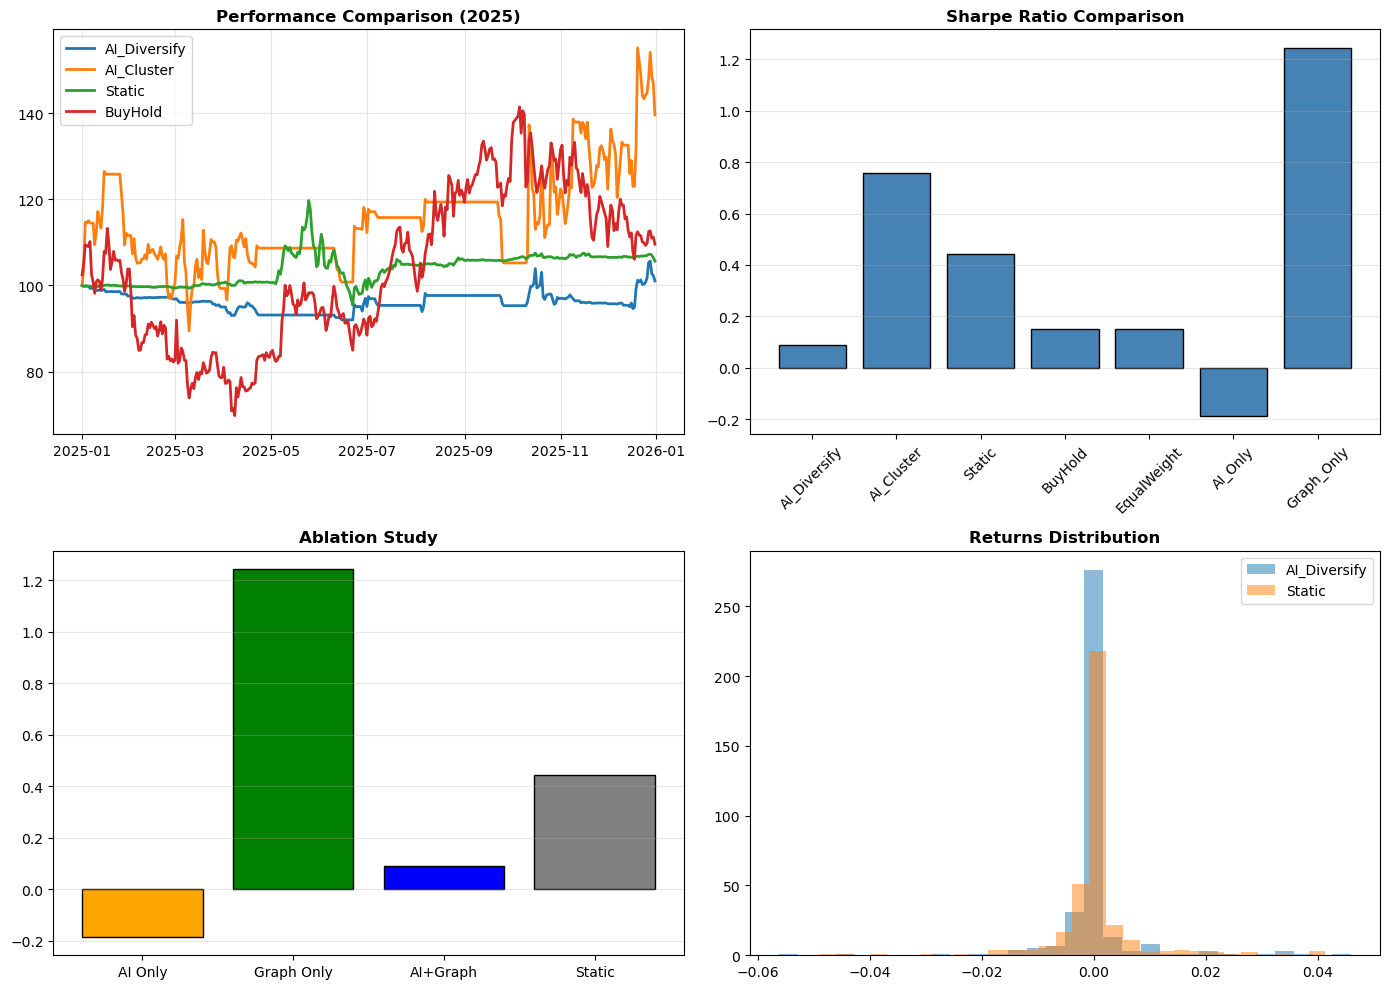

✓ Visualization saved


In [10]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Performance comparison
ax = axes[0, 0]
for k in ['AI_Diversify', 'AI_Cluster', 'Static', 'BuyHold']:
    ax.plot(results_2025[k].index, results_2025[k]['value'], label=k, linewidth=2)
ax.set_title('Performance Comparison (2025)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Sharpe comparison
ax = axes[0, 1]
sharpes = {k: m['Sharpe'] for k, m in metrics.items()}
ax.bar(sharpes.keys(), sharpes.values(), color='steelblue', edgecolor='black')
ax.set_title('Sharpe Ratio Comparison', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Ablation study
ax = axes[1, 0]
ablation = {'AI Only': metrics['AI_Only']['Sharpe'],
            'Graph Only': metrics['Graph_Only']['Sharpe'],
            'AI+Graph': metrics['AI_Diversify']['Sharpe'],
            'Static': metrics['Static']['Sharpe']}
ax.bar(ablation.keys(), ablation.values(), color=['orange','green','blue','gray'], edgecolor='black')
ax.set_title('Ablation Study', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Returns distribution
ax = axes[1, 1]
ax.hist(metrics['AI_Diversify']['Returns'], bins=30, alpha=0.5, label='AI_Diversify')
ax.hist(metrics['Static']['Returns'], bins=30, alpha=0.5, label='Static')
ax.set_title('Returns Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('thesis_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved")

In [11]:
# Export to Excel
summary_df = pd.DataFrame({k: {'Return%': m['Return%'], 'Volatility%': m['Vol%'], 
                               'Sharpe': m['Sharpe'], 'MaxDD%': m['MaxDD%']} 
                          for k, m in metrics.items()}).T

with pd.ExcelWriter('thesis_results.xlsx') as writer:
    summary_df.to_excel(writer, sheet_name='Metrics')
    for k, v in results_2025.items():
        v.to_excel(writer, sheet_name=k[:30])

print("✓ Excel exported: thesis_results.xlsx")

✓ Excel exported: thesis_results.xlsx


## CONCLUSIONS

1. **Statistical Significance**: Tested with paired t-tests (α=0.05)
2. **Ablation Study**: Isolated AI and Graph contributions
3. **Multiple Baselines**: Compared with 5 strategies
4. **Research Questions**: Answered with statistical evidence

**Key Findings** will depend on actual results!